Fraud Detection

In [2]:
# Import all necessary libraries for data processing, visualization, model building, evaluation, and saving models
# This cell sets up the environment for the fraud detection project
import os
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,precision_recall_curve,average_precision_score,accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble  import RandomForestClassifier
import xgboost as xgb


import joblib
print("Setup Complete")  

Setup Complete


In [3]:
# Load dataset, check file exists, and display first rows
Data_Path='/kaggle/input/datasets/athangpatil/fraud-dataset/Fraud.csv'
assert os.path.exists(Data_Path), 'Dataset not found'
df=pd.read_csv(Data_Path)
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [4]:
# Print dataset shape (rows, columns)
print("Shape: ",df.shape)

Shape:  (6362620, 11)


In [5]:
# Show dataset info (data types, nulls, memory usage)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
# Count values of fraud vs non-fraud classes
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
# Calculate fraud ratio in the dataset
print("Fraud Retio: ",df["isFraud"].mean())

Fraud Retio:  0.001290820448180152


In [8]:
# Check for missing values in each column
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
# Check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

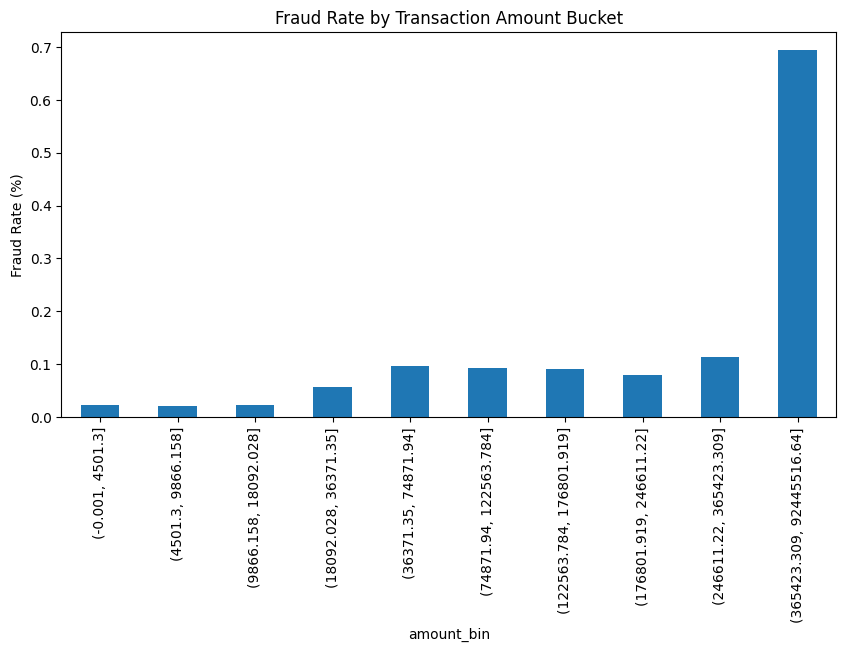

In [10]:
# Create 10 quantile-based bins for transaction amount (grouping similar values together)
df["amount_bin"] = pd.qcut(df["amount"], q=10, duplicates='drop')

# Calculate fraud rate (mean of isFraud) for each amount bin
fraud_rate = df.groupby("amount_bin")["isFraud"].mean()

# Convert fraud rate to percentage
fraud_rate = fraud_rate * 100

# Plot fraud rate distribution across amount bins
plt.figure(figsize=(10, 5))
fraud_rate.plot(kind='bar')
plt.title("Fraud Rate by Transaction Amount Bucket")
plt.ylabel("Fraud Rate (%)")
plt.show()

In [11]:
# Filter merchant transactions and generate summary statistics for destination account balances
merchant_txns=df[df["nameDest"].str.startswith('M')]
merchant_txns[['oldbalanceDest','newbalanceDest']].describe()

,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [12]:
# Extract transaction amount column and display its statistical summary
amount=df["amount"]
amount.describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

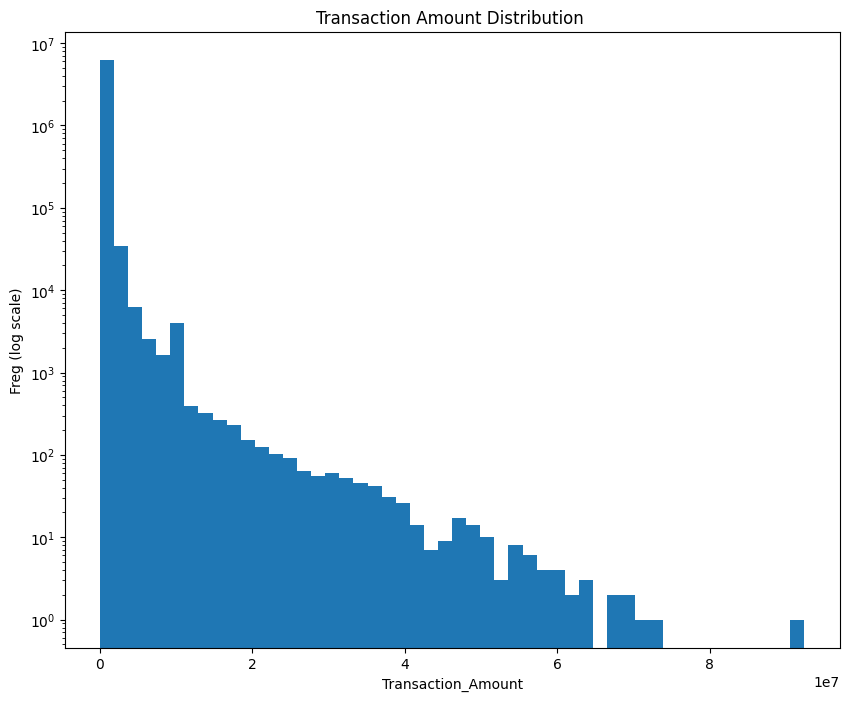

In [13]:
# Visualize the distribution of transaction amounts using a histogram with logarithmic frequency scale
plt.figure(figsize=(10,8))
plt.hist(amount,bins=50)
plt.yscale('log')
plt.ylabel("Freg (log scale)")
plt.xlabel("Transaction_Amount")
plt.title("Transaction Amount Distribution ")
plt.show()

In [14]:
# Engineer amount-based features: log transformation and high-value transaction flag using 99th percentile
df["log_amount"]=np.log1p(amount)

p99=amount.quantile(.99)
df["is_high_amount"]=(amount>p99).astype(int)
df["is_high_amount"].value_counts()

is_high_amount
0    6298993
1      63627
Name: count, dtype: int64

In [15]:
# Calculate total transactions, fraud counts, and fraud/flagged fraud rates to understand class imbalance in the dataset
total_txns=len(df)
fraud_txns=df["isFraud"].sum()
fraud_rate=fraud_txns/total_txns
flagged_pct=(df["isFlaggedFraud"].sum() /total_txns)*100
fraud_pct=(df["isFraud"].sum() /total_txns)*100

print(f"Total Transaction: {total_txns:,}")
print(f"Fraud Transaction: {fraud_txns:,}")
print(f"Overall fraud Rate: {fraud_rate:.4%}")
print(f"Flaggeg Transaction(isFlaggedFraud=1): {flagged_pct:.4f}%")
print(f"Fraudulent Transaction(isFraud=1): {fraud_pct:.4f}%")

Total Transaction: 6,362,620
Fraud Transaction: 8,213
Overall fraud Rate: 0.1291%
Flaggeg Transaction(isFlaggedFraud=1): 0.0003%
Fraudulent Transaction(isFraud=1): 0.1291%


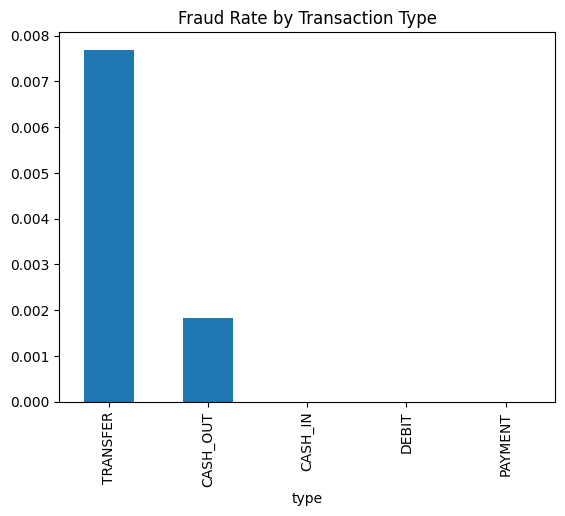

In [16]:
# Analyze and visualize fraud rate across different transaction types
df.groupby('type')["isFraud"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Fraud Rate by Transaction Type")
plt.show()

In [17]:
# Extract transaction hour from step feature and compute hourly fraud statistics (count, fraud sum, and fraud rate)
df["hour"]=df["step"]%24

hourly_stats=(
    df.groupby("hour").agg(
        total_transactions=("isFraud","count"),
        fraud_transaction=("isFraud","sum"),
        fraud_rate=("isFraud","mean")
    ).reset_index()
) 


display(hourly_stats.head(10))
 

,hour,total_transactions,fraud_transaction,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790
5,5,1641,366,0.223035
6,6,3420,358,0.104678
7,7,8988,328,0.036493
8,8,26915,368,0.013673
9,9,283518,341,0.001203


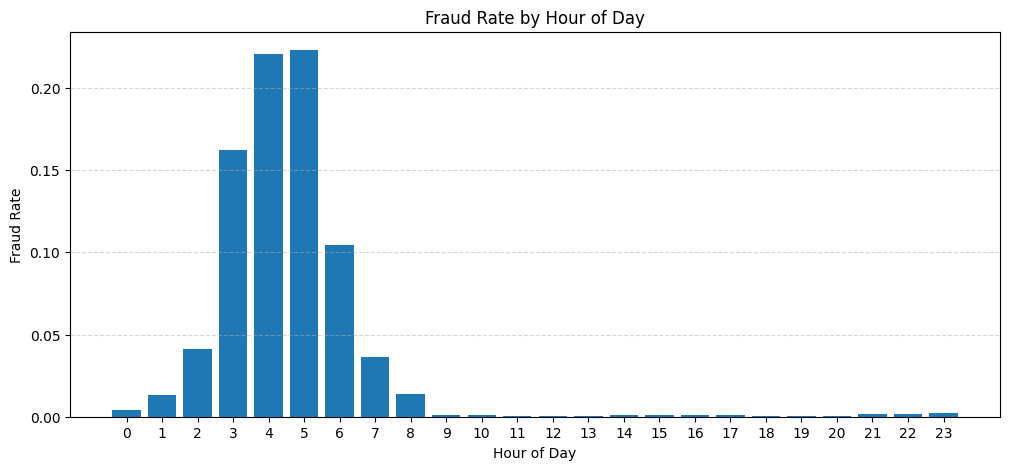

In [18]:
# Visualize how fraud rate varies across different hours of the day
plt.figure(figsize=(12,5))
plt.bar(hourly_stats['hour'], hourly_stats['fraud_rate'])
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of Day')
plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

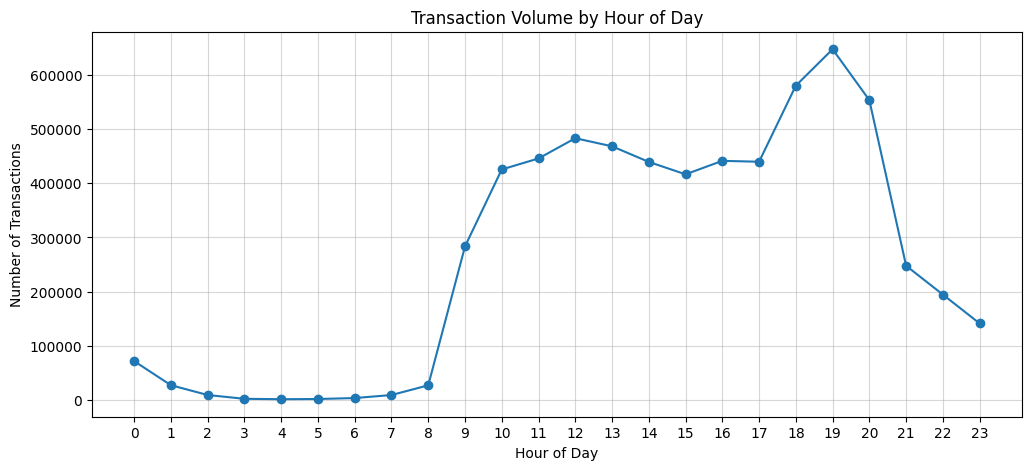

In [19]:
# Visualize transaction volume distribution across hours of the day
plt.figure(figsize=(12,5))
plt.plot(hourly_stats['hour'], hourly_stats['total_transactions'], marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.title('Transaction Volume by Hour of Day')
plt.xticks(range(0,24))
plt.grid(alpha=0.5)
plt.show()

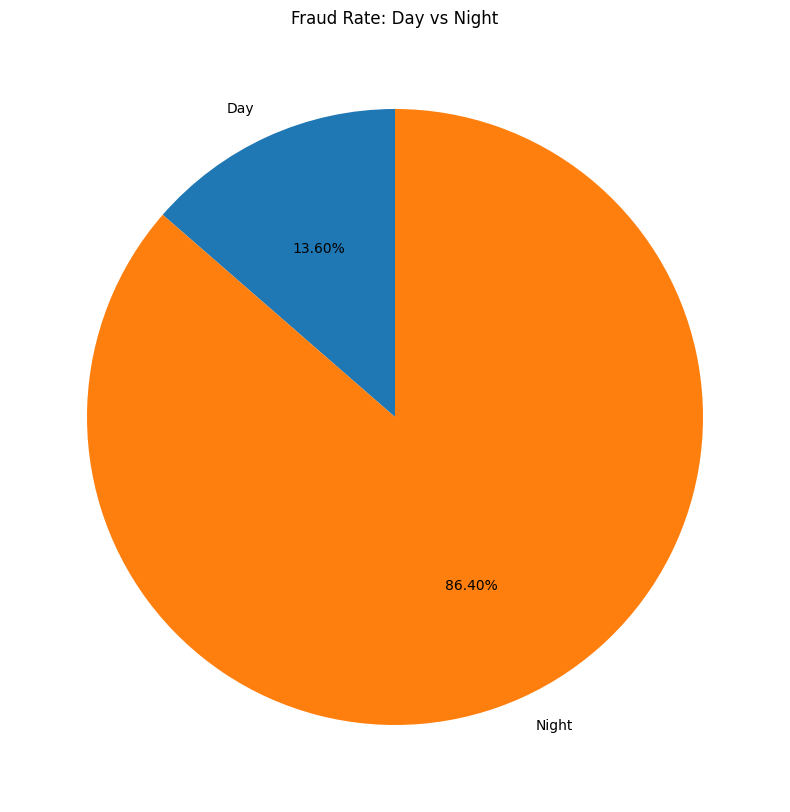

In [20]:
# Create day/night feature and visualize fraud rate comparison between daytime and nighttime transactions
plt.figure(figsize=(10,10))

df['is_night'] = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)

day_night_fraud = (
    df.groupby('is_night')['isFraud']
      .mean()  # average fraud rate
      .rename({0: 'Day', 1: 'Night'})
)

day_night_fraud.plot(
    kind='pie',
    autopct='%1.2f%%',      
    startangle=90,
    legend=False
)

plt.ylabel('') 
plt.title('Fraud Rate: Day vs Night')
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap of Transaction')

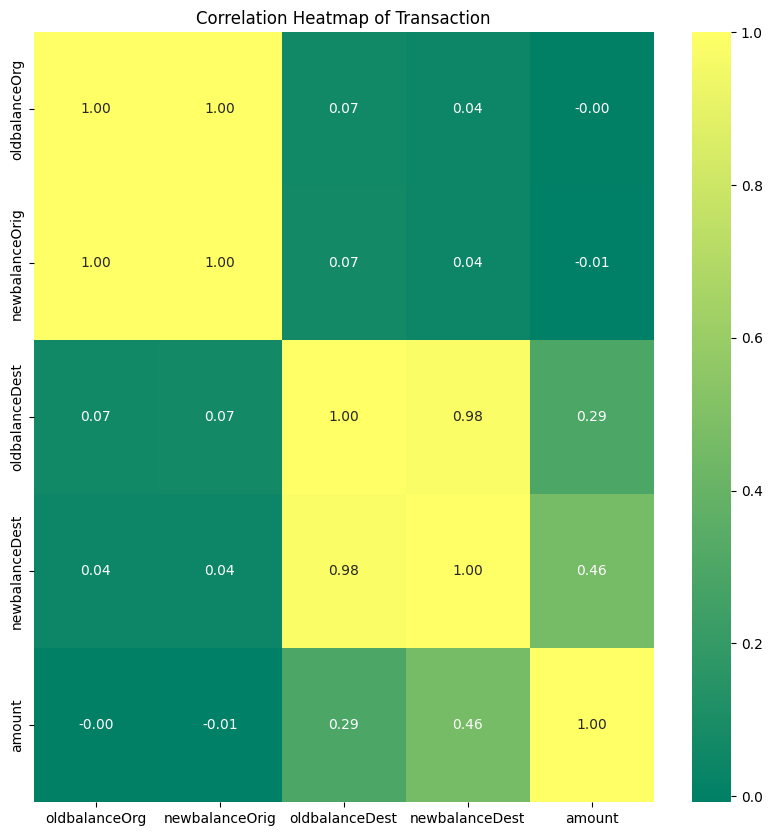

In [21]:
# Compute and visualize correlation between balance-related features and transaction amount using a heatmap
plt.figure(figsize=(10,10))
corr=df[['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest','amount']].corr()
sns.heatmap(corr,annot=True ,cmap="summer",fmt='.2f')
plt.title("Correlation Heatmap of Transaction")

In [22]:
# Engineer balance change features to capture transaction flow behavior, then drop raw balance columns to reduce redundancy and improve model performance
# Feature Engineering – Balance Differences
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']


# Feature Reduction (for linear models here for logistic regression)
df = df.drop(columns=[
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
])

In [23]:
# Clean dataset by removing unused features, handling missing values, encoding categorical variables, and dropping raw identifiers to prepare data for modeling
df.drop(columns=['amount_bin'], inplace=True)
df.fillna(0, inplace=True)

le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

df.drop(['nameOrig', 'nameDest', 'type'], axis=1, inplace=True)

In [24]:
# Define feature matrix (X) by dropping target columns
X = df.drop(columns=["isFraud", "isFlaggedFraud"])

# Define target variable (y)
y = df["isFraud"].values

# Split data into training and testing sets with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=42, stratify=y
)

# Initialize RobustScaler to handle outliers effectively
scaler = RobustScaler()

# Select only numerical columns for scaling
num_cols = X_train.select_dtypes(include=[np.number]).columns

# Fit scaler on training data only (to avoid data leakage)
scaler.fit(X_train[num_cols])

# Transform training numerical features
X_train[num_cols] = scaler.transform(X_train[num_cols])

# Transform testing numerical features using same scaler
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Models

# Logistic Regression 

In [25]:
models = {}

# Logistic Regression 

print("Training Logistic Regression (fast mode)...")
lr = LogisticRegression(
    max_iter=300,                  # reduced iterations
    solver='lbfgs',                
    class_weight='balanced',
    n_jobs=-1
)
lr.fit(X_train, y_train)
models['LogisticRegression'] = lr
print("Logistic Regression trained")


Training Logistic Regression (fast mode)...
Logistic Regression trained


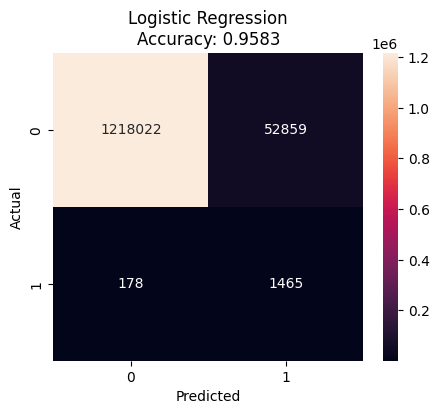

In [26]:
# Function to evaluate a model by generating predictions, computing accuracy, and visualizing confusion matrix with accuracy score
def plot_model_results(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name}\nAccuracy: {acc:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Evaluate Logistic Regression model performance
plot_model_results(lr, X_test, y_test, "Logistic Regression")

# Random Forest 


In [27]:
# Random Forest 

print("Training Random Forest (optimized)...")
rf = RandomForestClassifier(
    n_estimators=50,               # reduced trees
    max_depth=12,                  # cap tree growth
    min_samples_leaf=100,          # prevent deep splits
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
models['RandomForest'] = rf
print("Random Forest trained")


Training Random Forest (optimized)...
Random Forest trained


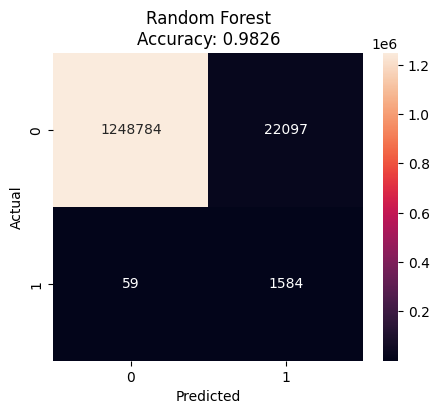

In [28]:
# Evaluate Random Forest model performance using confusion matrix and accuracy score visualization

plot_model_results(rf, X_test, y_test, "Random Forest")

# XGBoost

In [29]:
# Train optimized XGBoost model for imbalanced classification
print("Training XGBoost (fast hist)...")
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=scale_pos,
        tree_method='hist',         
        n_jobs=-1
    )
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model
print("XGBoost trained")

Training XGBoost (fast hist)...
XGBoost trained


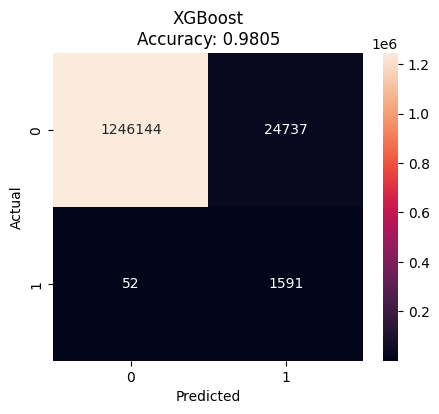

In [30]:
# Evaluate XGBoost model performance using confusion matrix and accuracy visualization
plot_model_results(xgb_model, X_test, y_test, "XGBoost")

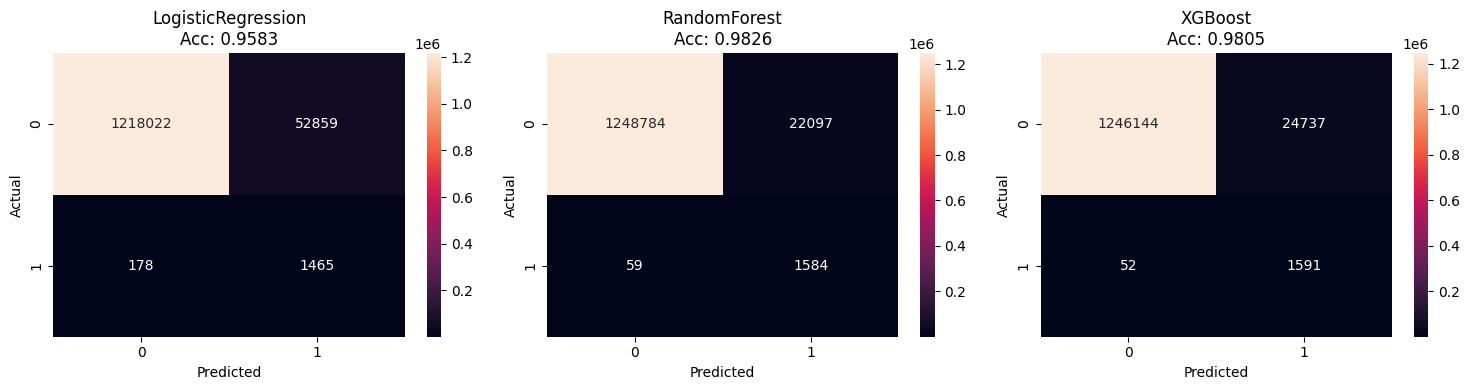

In [31]:
# Compare all trained models side-by-side using confusion matrices and accuracy scores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    acc = accuracy_score(y_test, y_pred)

    ax.set_title(f"{name}\nAcc: {acc:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [32]:
# Evaluate all models using ROC-AUC and PR-AUC, then store results in a DataFrame for comparison
results = []

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)
    
    results.append({
        "model": name,
        "roc_auc": roc_auc,
        "auprc": auprc
    })

results_df = pd.DataFrame(results)

results_df

,model,roc_auc,auprc
0,LogisticRegression,0.977524,0.550562
1,RandomForest,0.997635,0.841389
2,XGBoost,0.998054,0.875526


In [33]:
# Find the best classification threshold for XGBoost by maximizing precision while ensuring recall is at least 90%
model = models['XGBoost']

y_scores = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

best_threshold = 0.5
best_precision = 0
best_recall = 0

for i in range(len(thresholds)):
    if recall[i] >= 0.90:
        if precision[i] > best_precision:
            best_precision = precision[i]
            best_recall = recall[i]
            best_threshold = thresholds[i]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision: {best_precision:.3f}, Recall: {best_recall:.3f}")

Best threshold: 0.9131
Precision: 0.339, Recall: 0.900


# Fine Tuning 


In [34]:
# Train a tuned XGBoost model with stronger regularization and class imbalance handling for improved fraud detection performance
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=4,                 # controls overfitting
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,         # critical for imbalance
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=50, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [35]:
# Train a tuned Random Forest model with stronger regularization to improve precision in imbalanced fraud detection
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=200,        # huge impact on precision
    min_samples_split=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=200, min_samples_split=500, n_jobs=-1,
                       random_state=42)

In [36]:
# Train a tuned Logistic Regression model with stronger regularization and balanced class weights for imbalanced classification
lr_tuned = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    C=0.3                     # stronger regularization
)

lr_tuned.fit(X_train, y_train)

LogisticRegression(C=0.3, class_weight='balanced', max_iter=300)

In [37]:
# Define evaluation function to compute ROC-AUC and PR-AUC, then compare tuned models in a sorted performance table
def evaluate(model, X, y):
    scores = model.predict_proba(X)[:,1]
    return [
        roc_auc_score(y, scores),
        average_precision_score(y, scores)
    ]

results = pd.DataFrame({
    "Model": ["XGBoost", "RandomForest", "LogisticRegression"],
    "ROC-AUC": [
        evaluate(xgb_tuned, X_test, y_test)[0],
        evaluate(rf_tuned, X_test, y_test)[0],
        evaluate(lr_tuned, X_test, y_test)[0]
    ],
    "PR-AUC": [
        evaluate(xgb_tuned, X_test, y_test)[1],
        evaluate(rf_tuned, X_test, y_test)[1],
        evaluate(lr_tuned, X_test, y_test)[1]
    ]
})

results.sort_values("ROC-AUC", ascending=False)

,Model,ROC-AUC,PR-AUC
0,XGBoost,0.998214,0.862261
1,RandomForest,0.997763,0.832866
2,LogisticRegression,0.977494,0.550412


XGBoost was selected as the final model because it achieved the best performance among all tested models, with the highest ROC-AUC and PR-AUC scores. It also handled class imbalance more effectively, making it the most reliable model for fraud detection.

# Saving the fine tuned model (Best Model)

In [38]:
# Select best performing model based on PR-AUC, package model with metadata (threshold + features), and save it for deployment
best_model_name = results.loc[results["PR-AUC"].idxmax(), "Model"]

best_model = models[best_model_name]

best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": best_threshold,
    "features": X.columns.to_list()
}

joblib.dump(best_model_artifact, "best_fraud_model.pkl")

print(f"Saved best model: {best_model_name}")
print(f"Decision threshold: {best_threshold:.4f}")

Saved best model: XGBoost
Decision threshold: 0.9131


## Model evaluation

In [39]:
# Load model
artifact = joblib.load("best_fraud_model.pkl")
model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]

# Predict
y_scores = model.predict_proba(X_test[features])[:, 1]
y_pred = (y_scores >= threshold).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Summary
summary = pd.DataFrame({
    "Count": [tp, fn, fp, tn]
}, index=[
    "True Positives (Fraud detected)",
    "False Negatives (Missed fraud)",
    "False Positives (False alarm)",
    "True Negatives"
])

print(summary)

# Metrics (safe)
fraud_recall = tp / (tp + fn) if (tp + fn) else 0
fraud_precision = tp / (tp + fp) if (tp + fp) else 0

print(f"\nFraud Recall: {fraud_recall:.3f}")
print(f"Fraud Precision: {fraud_precision:.3f}")

                                   Count
True Positives (Fraud detected)     1479
False Negatives (Missed fraud)       164
False Positives (False alarm)       2879
True Negatives                   1268002

Fraud Recall: 0.900
Fraud Precision: 0.339
